<a href="https://colab.research.google.com/github/MihalkaProMuzon/Sentiment-Analysis/blob/main/Sentiment_Analysis_%D0%9D%D0%B0%D0%B4%D1%91%D0%B6%D0%BD%D0%BE%D1%81%D1%82%D1%8C_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85_%D0%B8_%D1%82%D1%80%D0%B0%D0%BD%D1%81%D1%84%D0%BE%D1%80%D0%BC%D0%B5%D1%80%D0%BD%D1%8B%D1%85_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D0%B2_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B5_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0_%D1%82%D0%BE%D0%BD%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D1%81%D1%82%D0%B8_%D0%BF%D1%80%D0%B8_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2%D0%BE%D0%BC_%D1%88%D1%83%D0%BC%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis: Надёжность классических и трансформерных моделей в задаче анализа тональности при текстовом шуме

<h2 > Автор </h2>

https://github.com/MihalkaProMuzon

Направление: Обработка естественного языка (NLP), классификация текста

Инструменты: Python, Scikit-learn, HuggingFace Transformers, PyTorch

Дата выполнения: 25.02.2026

В работе исследуется устойчивость моделей классификации тональности к различным типам текстового шума. Сравниваются классические линейные методы (TF-IDF + Logistic Regression, TF-IDF + Linear SVM) и трансформерная модель DistilBERT.

Эксперименты проводятся на датасете IMDb (50 000 размеченных отзывов). Помимо оценки качества на чистых данных, анализируется деградация моделей при добавлении символьных искажений (character noise) и случайного удаления слов (word dropout).

Цель исследования — определить, как архитектурные особенности моделей влияют на их поведение при нарушении структуры входного текста. Полученные результаты демонстрируют различную чувствительность линейных и трансформерных моделей к разным типам шума, что имеет практическое значение при выборе архитектуры для реальных сценариев.

<h2> Гипотезы для исследования </h2>

1. При отсутствии шума DistilBERT продемонстрирует более высокое качество по F1-score по сравнению с TF-IDF + линейными моделями.

2. При увеличении уровня символного шума качество линейных моделей будет снижаться быстрее из-за зависимости от точных n-грамм.

3. Трансформер будет демонстрировать большую устойчивость к умеренному шуму благодаря субсловной токенизации.

4. При высоком уровне word-dropout деградация качества DistilBERT будет более выраженной, так как модель чувствительна к контексту последовательности.

# Установка и импорт библиотек

In [ ]:
!pip -q install -U transformers accelerate datasets

# --- Базовые библиотеки и утилиты ---
import os  # Работа с операционной системой и файловой структурой
import random  # Генерация случайных чисел и выборка
import string  # Операции со строками и наборы символов

# --- Научные вычисления и анализ данных ---
import numpy as np  # Научные вычисления, работа с массивами
import pandas as pd  # Анализ и обработка табличных данных

# --- Визуализация ---
import matplotlib.pyplot as plt  # Построение графиков и визуализаций

# --- Обработка текста и регулярные выражения ---
import re  # Работа с регулярными выражениями для обработки текста

# --- Машинное обучение: scikit‑learn ---
from sklearn.model_selection import train_test_split, cross_val_score  # Разбиение данных на обучающую/тестовую выборки и кросс‑валидация
from sklearn.pipeline import Pipeline  # Создание пайплайнов обработки данных
from sklearn.linear_model import LogisticRegression  # Логистическая регрессия для классификации
from sklearn.svm import LinearSVC  # Линейный метод опорных векторов для классификации
from sklearn.feature_extraction.text import TfidfVectorizer  # Векторизация текста с использованием TF‑IDF
from sklearn.metrics import (
    f1_score,  # Расчёт F1‑меры (гармоническое среднее точности и полноты)
    accuracy_score,  # Расчёт точности классификации
    precision_recall_fscore_support  # Расчёт precision, recall и F1 с дополнительной информацией
)

# --- Библиотеки для работы с NLP‑датасетами ---
from datasets import load_dataset, Dataset  # Загрузка и работа с датасетами для NLP

# --- Глубокое обучение: PyTorch ---
import torch  # Фреймворк для глубокого обучения

# --- Трансформеры и NLP: Hugging Face Transformers ---
from transformers import (
    DistilBertTokenizerFast,  # Токенизатор для модели DistilBERT
    DistilBertForSequenceClassification,  # Модель DistilBERT для классификации последовательностей
    Trainer,  # Упрощённый интерфейс для обучения моделей
    TrainingArguments  # Аргументы и настройки процесса обучения
)

# --- Прогресс‑бары для длительных операций ---
from tqdm.auto import tqdm  # Отображение прогресс‑бара в консоли или Jupyter Notebook


# --- Фиксация Seed
def set_seed(seed: int = 42) -> None:
    """Fix random seeds for reproducibility across python/numpy (and pytorch if installed later)."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

SEED = 42
set_seed(SEED)

print("Seed fixed:", SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 117.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 18.8 MB/s eta 0:00:00
Seed fixed: 42


# Теоритическая часть

## Описание проблемы

Задача классификации тональности (Sentiment Analysis) заключается в определении эмоциональной окраски текста — в данном случае бинарной: положительный отзыв (1) или отрицательный отзыв (0).

Формально, требуется построить отображение:

$$
f: X \rightarrow Y
$$

где
$X$— пространство текстовых документов,

$Y = \{0,1\}$ — множество классов.

Особенность данной работы заключается не только в сравнении архитектур, но и в исследовании их устойчивости к искажению входных данных. В реальных сценариях текст может содержать:

- опечатки,
- неполные фразы,
- пропуски слов,
- ошибки ввода.

Поэтому помимо стандартной оценки качества на чистых данных, анализируется поведение моделей при добавлении контролируемого текстового шума.

## Основные концепции

### TF-IDF

TF-IDF (Term Frequency – Inverse Document Frequency) — способ представления текста в виде числового вектора.

Вес термина $t$ в документе $d$:

$$
TFIDF(t, d) = TF(t, d) \cdot IDF(t)
$$

где

$$ TF(t, d) = \frac{f_{t,d}}{\sum_k f_{k,d}} $$
,
$$ IDF(t) = \log\left(\frac{N}{df_t}\right) $$

$f_{t,d}$ — частота термина в документе,

$df_t$ — количество документов, содержащих термин,

$N$ — общее число документов.


### Логистическая регрессия

Логистическая регрессия — линейная модель бинарной классификации.

Вероятность принадлежности классу 1 определяется как:

$$
P(y=1|x) = \sigma(w^T x + b)
$$

где

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$
— сигмоидная функция.

Оптимизация проводится путём минимизации функции потерь бинарной кросс-энтропии:

$$
\mathcal{L} = - \frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \right]
$$

Регуляризация контролируется параметром $C$.

### Линейный SVM

Linear Support Vector Machine строит линейную разделяющую гиперплоскость:

$$
w^T x + b = 0
$$

Оптимизация направлена на максимизацию зазора между классами:

$$
\min_{w,b} \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} \xi_i
$$

где
$\xi_i$ — штраф за ошибки классификации.

Параметр $C$ регулирует компромисс между шириной зазора и количеством ошибок.


### DistilBERT и трансформерная архитектура

DistilBERT представляет собой упрощённую версию архитектуры BERT, полученную методом knowledge distillation.

Модель состоит из:
- входного слоя токенизации (WordPiece),
- эмбеддингов токенов и позиций,
- стека Transformer Encoder-блоков (в DistilBERT их 6 вместо 12 в BERT-base),
- классификационной головы (линейный слой).

Каждый Encoder-блок включает:
- Multi-Head Self-Attention,
- Feed-Forward Network,
- Residual connections,
- Layer Normalization.

DistilBERT сохраняет большую часть семантической мощности BERT при меньшем количестве параметров и более высокой скорости обучения.

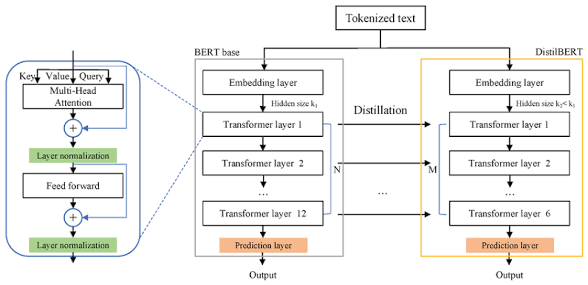

Ключевой компонент трансформера — механизм внимания:

$$
Attention(Q,K,V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

где:

* $Q$ — запросы,
* $K$ — ключи,
* $V$ — значения,
* $d_k$ — размерность ключей.

Self-attention позволяет каждому токену учитывать контекст всей последовательности.

Модель использует субсловную токенизацию *WordPiece*, что позволяет работать с редкими и неизвестными словами.

В задаче классификации используется fine-tuning предобученной модели путём добавления классификационной головы и минимизации кросс-энтропии.

## Методология эксперимента

### Данные и разбиение

В работе используется датасет **IMDb Reviews**, содержащий 50 000 размеченных отзывов, разделённых на:

* **Train**: 25 000 примеров
* **Test**: 25 000 примеров



Для подбора гиперпараметров из обучающей выборки дополнительно выделяется валидационная подвыборка:

$$
Train \rightarrow Train_{inner} (90\%) + Validation (10\%)
$$
Разделение выполняется стратифицированно по метке класса с фиксированным random seed, что обеспечивает воспроизводимость результатов.

Тестовая выборка используется **строго один раз** для финальной оценки качества и анализа устойчивости.


### Протокол обучения линейных моделей

Для классических моделей используется следующий pipeline:

$$
Text \rightarrow Cleaning \rightarrow TF\text{-}IDF \rightarrow Linear\ Classifier
$$

Параметры TF-IDF (фиксированы):

* ngram_range = (1, 2)
* max_features = 50 000
* min_df = 2
* max_df = 0.95
* strip_accents = "unicode"


Оптимизируется только параметр регуляризации:

$$
C \in {0.1, 0.5, 1.0, 2.0, 3.0}
$$

Оценка выполняется с использованием 3-fold cross-validation на $Train_{inner}$.

Критерий выбора — максимизация **F1-score (binary)**.

После выбора оптимального $C$ модель переобучается на полном Train и оценивается на Test.

### Протокол обучения DistilBERT

Используется предобученная модель:

$$
\text{distilbert-base-uncased}
$$

Фиксированные параметры:

* max_length = 256
* batch_size = 32
* num_train_epochs = 2
* weight_decay = 0.01

Оптимизируется только learning rate:

$$
lr \in {5 \times 10^{-5}, 3 \times 10^{-5}, 2 \times 10^{-5}}
$$

Оценка производится на Validation по метрике F1-score.

Лучшая конфигурация выбирается по максимальному значению F1.

После выбора learning rate модель дообучается на полном Train и оценивается на Test.


### Метрики оценки

Основной метрикой является:

$$
F1 = \frac{2 \cdot Precision \cdot Recall}{Precision + Recall}
$$

где

$$
Precision = \frac{TP}{TP + FP}
$$
,

$$
Recall = \frac{TP}{TP + FN}
$$

Дополнительно рассчитываются:

* Accuracy
* Precision
* Recall

Выбор F1-score обусловлен необходимостью учитывать баланс между полнотой и точностью при бинарной классификации.


### Протокол эксперимента по шумоустойчивости

Для анализа устойчивости вводится оператор искажения:

$$
\tilde{x} = \mathcal{N}(x, \alpha)
$$

где:

* $x$ — исходный текст,
* $\alpha$ — уровень шума,
* $\mathcal{N}$ — функция искажения.


Рассматриваются два типа шума:

<h3> 1. Character Noise </h3>

С вероятностью $\alpha$ для каждого символа выполняется одна из операций:

* swap (перестановка соседних символов),
* delete (удаление),
* replace (замена случайным символом).

<h3> 2. Word Dropout </h3>

Каждое слово удаляется с вероятностью $\alpha$.

<h3> Уровни шума: </h3>

$$
\alpha \in {0.0, 0.05, 0.10, 0.15, 0.20, 0.3}
$$

Шум применяется **исключительно к тестовой выборке**.

Модели не дообучаются на зашумлённых данных, что позволяет измерить чистую устойчивость архитектур к деградации входного текста.

### Вычислительные ограничения

Эксперименты выполняются в среде Google Colab с ограничением общего времени выполнения кода (< 2 часов).

Для соблюдения ограничений:

* ограничено пространство поиска гиперпараметров,
* используется DistilBERT вместо BERT-base,
* фиксировано число эпох обучения,
* оптимизирован размер batch,
* сохранены промежуточные артефакты.

# Подготовка данных

## Загрузка датасета

In [ ]:
# Загрузка датасета IMDb + базовая структура

ds = load_dataset("stanfordnlp/imdb")
train_df = pd.DataFrame(ds["train"])
test_df  = pd.DataFrame(ds["test"])

print("=== БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ ===\n")
print(f"- Train: {len(train_df):,}")
print(f"- Test : {len(test_df):,}")
print(f"- Total: {len(train_df) + len(test_df):,}\n")

print("Dataset structure:\n", ds, "\n")

print("Train columns info:")
display(train_df.info())

display(train_df.head(3))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

=== БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ ===

- Train: 25,000
- Test : 25,000
- Total: 50,000

Dataset structure:
 DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
}) 

Train columns info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


None

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0


Выведем несколько примеров данных

In [ ]:
# Примеры

random_sample = train_df.sample(n=5, random_state=SEED)

for _, row in random_sample.iterrows():
    lbl = int(row["label"])
    prefix = "positive (1)" if lbl == 1 else "negative (0)"
    text_preview = row["text"]
    print(f"{prefix}> {text_preview}\n")

negative (0)> Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what starts out as Chris Klein trying to maintain a low profile, eventually morphs into an uninspired version of "The Three Amigos", only without any laughs. In order for black comedy to work, it must be outrageous, which "Play Dead" is not. In order for black comedy to work, it cannot be mean spirited, which "Play Dead" is. What "Play Dead" really is, is a town full of nut jobs. Fred Dunst does however do a pretty fair imitation of Billy Bob Thornton's character from "A Simple Plan", while Jake Busey does a pretty fair imitation of, well, Jake Busey. - MERK

positive (1)> I dug out from my garage some old musicals and this is another one of my favorites. It was written by Jay Alan Lerner and directed by Vincent Minelli. It won two Academy Awards for Best Picture of 1951 and Best Screenplay. The story of an American painter in Paris who tries to make it big. Nina Foch is a sophistic

## EDA


=== Label distribution: train ===


,count,percent
label,,
0,12500,50.0
1,12500,50.0



=== Label distribution: test ===


,count,percent
label,,
0,12500,50.0
1,12500,50.0


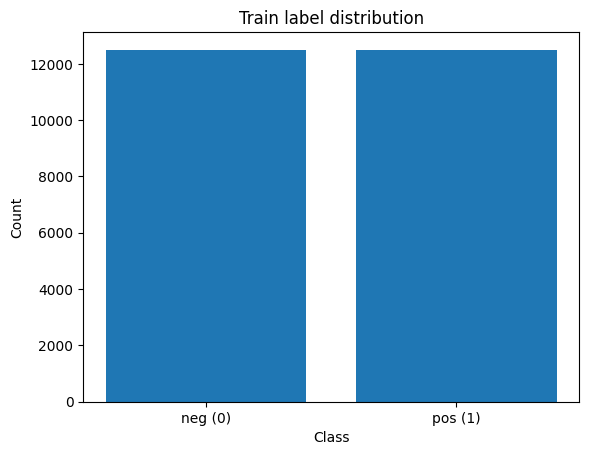

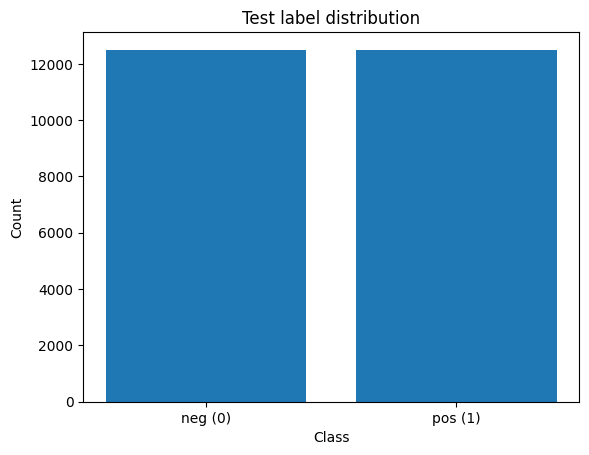

In [ ]:
# @title Проверка распределения классов

def label_distribution(df: pd.DataFrame, name: str) -> pd.Series:
    counts = df["label"].value_counts().sort_index()
    perc = (counts / counts.sum() * 100).round(2)
    dist = pd.DataFrame({"count": counts, "percent": perc})
    print(f"\n=== Label distribution: {name} ===")
    display(dist)
    return counts

train_counts = label_distribution(train_df, "train")
test_counts  = label_distribution(test_df, "test")

# Plot
plt.figure()
plt.bar(["neg (0)", "pos (1)"], [train_counts.get(0, 0), train_counts.get(1, 0)])
plt.title("Train label distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.bar(["neg (0)", "pos (1)"], [test_counts.get(0, 0), test_counts.get(1, 0)])
plt.title("Test label distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Вывод: классы сбалансированы


=== Length stats: train ===


,n_chars,n_words
count,25000.00,25000.00
mean,1325.07,233.79
std,1003.13,173.73
min,52.00,10.00
50%,979.00,174.00
90%,2617.00,458.00
95%,3432.05,598.00
99%,5213.01,913.00
max,13704.00,2470.00



=== Length stats: test ===


,n_chars,n_words
count,25000.00,25000.00
mean,1293.79,228.53
std,975.91,168.88
min,32.00,4.00
50%,962.00,172.00
90%,2544.10,444.00
95%,3333.00,582.05
99%,5138.09,901.00
max,12988.00,2278.00


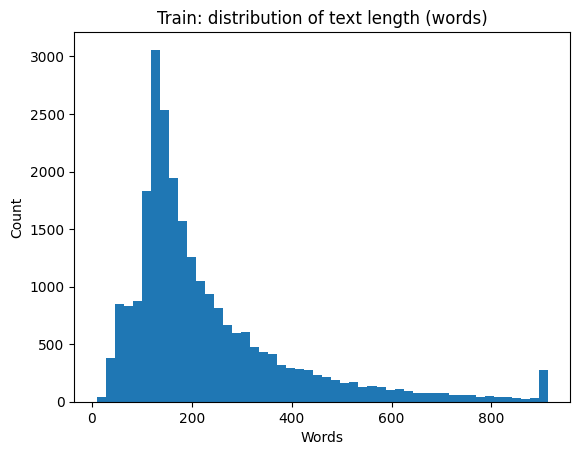

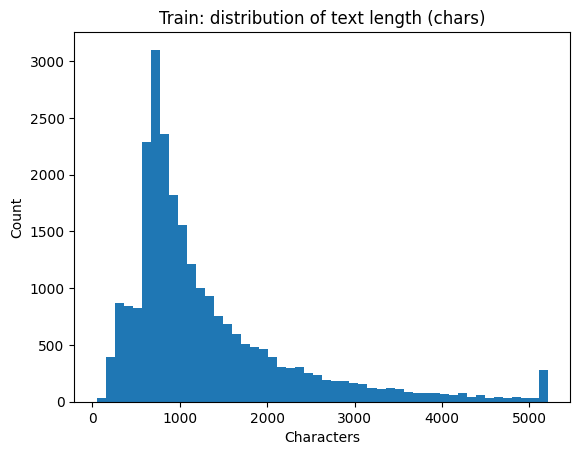

In [ ]:
# @title Распределение длин текстов

def add_length_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["n_chars"] = out["text"].astype(str).str.len()
    out["n_words"] = out["text"].astype(str).str.split().apply(len)
    return out

train_df_eda = add_length_features(train_df)
test_df_eda  = add_length_features(test_df)

def describe_lengths(df: pd.DataFrame, name: str) -> None:
    print(f"\n=== Length stats: {name} ===")
    display(df[["n_chars", "n_words"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))

describe_lengths(train_df_eda, "train")
describe_lengths(test_df_eda, "test")

# Histograms (trim extreme tails to make plots readable)
def plot_hist(series: pd.Series, title: str, xlabel: str, clip_q: float = 0.99):
    clipped = series.clip(upper=series.quantile(clip_q))
    plt.figure()
    plt.hist(clipped, bins=50)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

plot_hist(train_df_eda["n_words"], "Train: distribution of text length (words)", "Words", clip_q=0.99)
plot_hist(train_df_eda["n_chars"], "Train: distribution of text length (chars)", "Characters", clip_q=0.99)


=== Length by class: train ===


n_words                                                              \
         count    mean     std   min    50%    90%     95%     99%     max   
label                                                                        
0      12500.0  230.87  166.66  10.0  174.0  441.0  575.00  892.03  1522.0   
1      12500.0  236.71  180.49  12.0  174.0  472.0  619.05  924.00  2470.0   

       n_chars                                                          \
         count     mean      std   min    50%     90%     95%      99%   
label                                                                    
0      12500.0  1302.98   957.07  52.0  976.5  2510.0  3282.0  5093.04   
1      12500.0  1347.16  1046.75  70.0  982.0  2739.3  3564.0  5293.08   

                
           max  
label           
0       8969.0  
1      13704.0

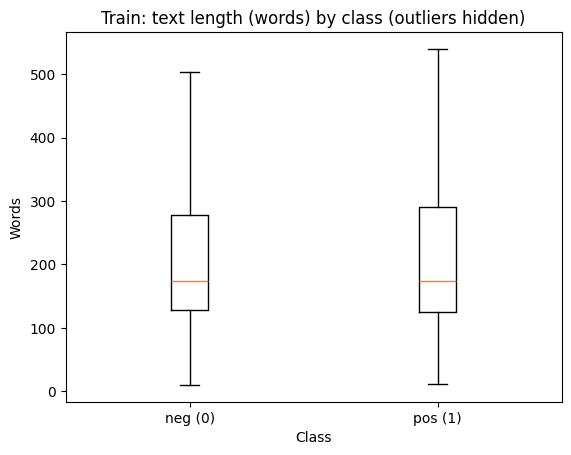

In [ ]:
# @title Длины по классам

def length_by_class(df: pd.DataFrame, name: str) -> None:
    grouped = df.groupby("label")[["n_words", "n_chars"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2)
    print(f"\n=== Length by class: {name} ===")
    display(grouped)

length_by_class(train_df_eda, "train")

# Boxplot-like visualization via violin? (без seaborn — сделаем простые boxplots)
plt.figure()
plt.boxplot(
    [train_df_eda.loc[train_df_eda["label"] == 0, "n_words"],
     train_df_eda.loc[train_df_eda["label"] == 1, "n_words"]],
    tick_labels=["neg (0)", "pos (1)"],
    showfliers=False
)
plt.title("Train: text length (words) by class (outliers hidden)")
plt.xlabel("Class")
plt.ylabel("Words")
print('\n')
plt.show()

In [ ]:
# @title sanity-check по “шумным” элементам (HTML-теги, спецсимволы)

def html_tag_ratio(df: pd.DataFrame, pattern: str = r"<br\s*/?>") -> float:
    has_tag = df["text"].astype(str).str.contains(pattern, regex=True)
    return float(has_tag.mean())

ratio_train = html_tag_ratio(train_df)
ratio_test  = html_tag_ratio(test_df)

print(f"Train: share of texts with <br/> tag ≈ {ratio_train:.3f}")
print(f"Test : share of texts with <br/> tag ≈ {ratio_test:.3f}")

# Show a few examples containing HTML breaks
examples = train_df[train_df["text"].str.contains(r"<br\s*/?>", regex=True)].sample(3, random_state=SEED)
for _, row in examples.iterrows():
    print("\n--- Example with HTML tag ---")
    print(row["text"][:600], "...")

Train: share of texts with <br/> tag ≈ 0.587
Test : share of texts with <br/> tag ≈ 0.581

--- Example with HTML tag ---
Filmfour are going to have to do a lot better than this little snot of a film if they're going to get the right sort of reputation for themselves.<br /><br />This film is set in Glasgow (although only a couple of secondary characters have anything approaching a Scottish accent). The premise, about people who's lives are going nowhere, who all meet up in the same cafe in the early hours of the morning as they have night jobs, COULD have made for a really funny, insightful, quirky, cultish film. Instead we have a group of self-obsessed saddos and a plot which has been so done to bits I'm suprise ...

--- Example with HTML tag ---
I saw this dull waste of time on HBO's Comedy Channel, so I quite innocently and obviously assumed that this was a comedy. But there is absolutely nothing funny here. A good cast is basically wasted on a script that I could have written with m

### Выводы по EDA

Датасет IMDb содержит 50 000 размеченных отзывов и официально разделён на train (25k) и test (25k), что упрощает воспроизводимое сравнение моделей и исключает риск утечки данных.

Распределение меток показывает практически идеальный баланс классов (50% положительных и 50% отрицательных отзывов). В таких условиях метрика Accuracy остаётся информативной. Тем не менее в качестве основной метрики используется F1-score (binary), поскольку она учитывает баланс между precision и recall и чувствительна к ошибкам классификации.

Анализ длины текстов (в словах и символах) показывает выраженный длинный хвост: часть отзывов значительно превышает среднюю длину. Это оказывает влияние на выбор архитектурных и вычислительных параметров моделей.

<h3> Ограничение длины для трансформера </h3>

Трансформерные модели имеют ограничение на максимальную длину входной последовательности. В работе выбрано:

$$
\text{max_length} = 256
$$

Выбор обусловлен следующими факторами:

* большинство отзывов укладываются в 256 токенов после WordPiece-токенизации;
* увеличение длины до 512 существенно повышает вычислительную стоимость;
* ограничение необходимо для соблюдения временных ограничений Google Colab (< 2 часов выполнения).

Таким образом, 256 токенов представляет собой компромисс между сохранением контекста и вычислительной эффективностью.

Линейные модели не ограничиваются длиной документа и используют весь текст целиком.

<h3> Выбор n-грамм для TF-IDF </h3>

Векторизация выполняется с использованием:


$$
\text{ngram_range} = (1,2)
$$

Выбор обусловлен тем, что:

* униграммы фиксируют отдельные ключевые слова (good, bad, boring);
* биграммы позволяют учитывать локальный контекст (not good, very bad);
* использование более длинных n-грамм резко увеличивает размерность пространства признаков без существенного прироста качества.

Таким образом, диапазон (1,2) обеспечивает баланс между выразительностью модели и контролем размерности признакового пространства.

## Очистка текста

Функция очистки текста

In [ ]:
def clean_text(text: str, lowercase: bool = True) -> str:
    """
    Minimal cleaning:
    - remove HTML line breaks
    - normalize spaces
    - optional lowercasing (for baseline)
    """
    text = str(text)

    # Remove HTML break tags
    text = re.sub(r"<br\s*/?>", " ", text)

    # Remove excessive whitespace
    text = re.sub(r"\s+", " ", text).strip()

    if lowercase:
        text = text.lower()

    return text

Датасеты для линейных моделей (baseline) и DistillBERT

In [ ]:
# Для baseline (lowercase = True)

train_df["clean_text_baseline"] = train_df["text"].apply(lambda x: clean_text(x, lowercase=True))
test_df["clean_text_baseline"]  = test_df["text"].apply(lambda x: clean_text(x, lowercase=True))

# Для DistilBERT (lowercase = False)
# сам делает lowercasing внутри tokenizer, поэтому ручной не требуется.

train_df["clean_text_bert"] = train_df["text"].apply(lambda x: clean_text(x, lowercase=False))
test_df["clean_text_bert"]  = test_df["text"].apply(lambda x: clean_text(x, lowercase=False))

Проверка работы функции очистки

In [ ]:
print("=== Before cleaning ===\n")
print(train_df["text"].iloc[0][:500])

print("\n=== After baseline cleaning ===\n")
print(train_df["clean_text_baseline"].iloc[0][:500])

=== Before cleaning ===

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

=== After baseline cleaning ===

i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" i really had to see this for myself. the plot is centered around a young swedish drama student named lena who wants to learn everything she can about 

## Формирование выборок

Разделение входных данных по типу модели

Для линейных моделей используется версия текста с предварительной очисткой (baseline cleaning), тогда как для трансформера применяется минимальная обработка, поскольку DistilBERT использует собственную субсловную токенизацию.

In [ ]:
X_train_base = train_df["clean_text_baseline"].values
y_train = train_df["label"].values

X_test_base = test_df["clean_text_baseline"].values
y_test = test_df["label"].values

X_train_bert = train_df["clean_text_bert"].values
X_test_bert  = test_df["clean_text_bert"].values

print("Shapes:")
print("Baseline train:", X_train_base.shape)
print("BERT train:", X_train_bert.shape)

Shapes:
Baseline train: (25000,)
BERT train: (25000,)


Из обучающей выборки выделяется 10% данных для подбора гиперпараметров. Тестовая выборка остаётся неизменной и используется только для финальной оценки.

In [ ]:
X_train_full = train_df["clean_text_baseline"].values
y_train_full = train_df["label"].values

X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1,
    stratify=y_train_full,
    random_state=SEED
)

print("Train_inner:", len(X_train_inner))
print("Validation :", len(X_val))

Train_inner: 22500
Validation : 2500


Подготовка данных для DistilBERT

Тексты преобразуются в формат HuggingFace Dataset, затем токенизируются с использованием WordPiece-токенизатора. После этого данные приводятся к формату PyTorch для обучения модели с использованием Trainer API.

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LENGTH = 256

def tokenize_batch(texts):
    return tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

# Создаём HF Dataset
train_inner_ds = Dataset.from_dict({
    "text": X_train_inner,
    "label": y_train_inner
})

val_ds = Dataset.from_dict({
    "text": X_val,
    "label": y_val
})

train_inner_ds = train_inner_ds.map(lambda x: tokenize_batch(x["text"]), batched=True)
val_ds = val_ds.map(lambda x: tokenize_batch(x["text"]), batched=True)

train_inner_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Полные данные
train_full_ds = Dataset.from_dict({
    "text": X_train_bert,
    "label": y_train
})

train_full_ds = train_full_ds.map(lambda x: tokenize_batch(x["text"]), batched=True)
train_full_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

test_ds = Dataset.from_dict({
    "text": X_test_bert,
    "label": y_test
})

test_ds = test_ds.map(lambda x: tokenize_batch(x["text"]), batched=True)
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

# Обучение моделей

## Logistic Regression

Поиск оптимального $C$

In [ ]:
C_values = [0.1, 0.5, 1.0, 2.0, 3.0]

results_logreg = []

for C in tqdm(C_values):

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=50000,
            min_df=2,
            max_df=0.95,
            strip_accents="unicode"
        )),
        ("clf", LogisticRegression(
            C=C,
            max_iter=2000,
            random_state=SEED
        ))
    ])

    scores = cross_val_score(
        pipeline,
        X_train_inner,
        y_train_inner,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    results_logreg.append({
        "C": C,
        "mean_f1": np.mean(scores),
        "std_f1": np.std(scores)
    })

results_logreg_df = pd.DataFrame(results_logreg).sort_values("mean_f1", ascending=False)
results_logreg_df

  0%|          | 0/5 [00:00<?, ?it/s]

,C,mean_f1,std_f1
4,3.0,0.896544,0.003682
3,2.0,0.894689,0.003386
2,1.0,0.890655,0.002987
1,0.5,0.882267,0.002820
0,0.1,0.850961,0.002004


Выбор лучшего $C$

In [ ]:
best_C_logreg = results_logreg_df.iloc[0]["C"]
print("Best C (LogReg):", best_C_logreg)

Best C (LogReg): 3.0


Финальное обучение при оптимальном $C$ и тестирование

In [ ]:
best_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2,
        max_df=0.95,
        strip_accents="unicode"
    )),
    ("clf", LogisticRegression(
        C=best_C_logreg,
        max_iter=2000,
        random_state=SEED
    ))
])

best_logreg.fit(X_train_full, y_train_full)

y_test_pred_logreg = best_logreg.predict(X_test_base)

from sklearn.metrics import classification_report

print("\nFinal TEST results (LogReg):")
print(classification_report(y_test, y_test_pred_logreg, digits=4))


Final TEST results (LogReg):
              precision    recall  f1-score   support

           0     0.8995    0.9007    0.9001     12500
           1     0.9006    0.8994    0.9000     12500

    accuracy                         0.9000     25000
   macro avg     0.9000    0.9000    0.9000     25000
weighted avg     0.9000    0.9000    0.9000     25000



## Linear SVM

Поиск оптимального $C$

In [ ]:
results_svm = []

for C in tqdm(C_values):

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=50000,
            min_df=2,
            max_df=0.95,
            strip_accents="unicode"
        )),
        ("clf", LinearSVC(
            C=C,
            random_state=SEED
        ))
    ])

    scores = cross_val_score(
        pipeline,
        X_train_inner,
        y_train_inner,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    results_svm.append({
        "C": C,
        "mean_f1": np.mean(scores),
        "std_f1": np.std(scores)
    })

results_svm_df = pd.DataFrame(results_svm).sort_values("mean_f1", ascending=False)
results_svm_df

  0%|          | 0/5 [00:00<?, ?it/s]

,C,mean_f1,std_f1
1,0.5,0.899576,0.002944
2,1.0,0.898846,0.002653
3,2.0,0.895228,0.002400
4,3.0,0.893583,0.002536
0,0.1,0.892471,0.003999


Выбор лучшего $C$

In [ ]:
best_C_svm = results_svm_df.iloc[0]["C"]
print("Best C (LinearSVM):", best_C_svm)

Best C (LinearSVM): 0.5


Финальное обучение при оптимальном $C$ и тестирование

In [ ]:
best_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2,
        max_df=0.95,
        strip_accents="unicode"
    )),
    ("clf", LinearSVC(
        C=best_C_svm,
        random_state=SEED
    ))
])

best_svm.fit(X_train_full, y_train_full)

y_test_pred_svm = best_svm.predict(X_test_base)

print("\nFinal TEST results (LinearSVM):")
print(classification_report(y_test, y_test_pred_svm, digits=4))


Final TEST results (LinearSVM):
              precision    recall  f1-score   support

           0     0.8971    0.9027    0.8999     12500
           1     0.9021    0.8965    0.8993     12500

    accuracy                         0.8996     25000
   macro avg     0.8996    0.8996    0.8996     25000
weighted avg     0.8996    0.8996    0.8996     25000



## DistillBERT

Функция вычисления метрик, гиперпараметры

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    pr, rc, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision": pr,
        "recall": rc,
        "f1": f1
    }

LEARNING_RATES = [5e-5, 3e-5, 2e-5]
EPOCHS = 2
BATCH_SIZE = 32

Поиск оптимального $lr$

In [ ]:
bert_results = []

for lr in LEARNING_RATES:

    print(f"\n===== Training with lr={lr} =====")

    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./bert_lr_{lr}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        logging_steps=100,
        seed=SEED,
        load_best_model_at_end=False,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_inner_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()

    eval_metrics = trainer.evaluate()

    bert_results.append({
        "learning_rate": lr,
        "val_f1": eval_metrics["eval_f1"],
        "val_accuracy": eval_metrics["eval_accuracy"]
    })

bert_results_df = pd.DataFrame(bert_results).sort_values("val_f1", ascending=False)
bert_results_df


===== Training with lr=5e-05 =====


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...


===== Training with lr=2e-05 =====


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.242426,0.246063,0.896000,0.881944,0.914400,0.897879
2,0.171154,0.246372,0.904400,0.899605,0.910400,0.904970


,learning_rate,val_f1,val_accuracy
0,0.00005,0.915873,0.9152
1,0.00003,0.909670,0.9092
2,0.00002,0.904970,0.9044


Выбор оптимального $lr$

In [ ]:
best_lr = bert_results_df.iloc[0]["learning_rate"]
print("Best learning rate:", best_lr)

Best learning rate: 5e-05


Финальный train при оптимальном $lr$

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./bert_final",
    eval_strategy="no",
    save_strategy="no",
    learning_rate=best_lr,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_steps=100,
    seed=SEED,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_full_ds,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.414134
200,0.300162
300,0.280280
400,0.278645
500,0.261152
600,0.256556
700,0.235686
800,0.221149
900,0.139165
1000,0.148394


TrainOutput(global_step=1564, training_loss=0.20913840559742336, metrics={'train_runtime': 1052.4903, 'train_samples_per_second': 47.506, 'train_steps_per_second': 1.486, 'total_flos': 3311684966400000.0, 'train_loss': 0.20913840559742336, 'epoch': 2.0})

Тестирование обученной модели

In [ ]:
test_metrics = trainer.evaluate(test_ds)

print("\nFinal TEST results (DistilBERT):")
print(test_metrics)


Final TEST results (DistilBERT):
{'eval_loss': 0.24817311763763428, 'eval_accuracy': 0.91864, 'eval_precision': 0.9109470708339877, 'eval_recall': 0.928, 'eval_f1': 0.9193944677815645, 'eval_runtime': 172.3069, 'eval_samples_per_second': 145.09, 'eval_steps_per_second': 4.538, 'epoch': 2.0}


# Эксперименты по шумоустойчивости

Функции добавления шума в выборки

In [ ]:
def apply_char_noise(text, noise_level=0.1):
    """
    Apply character-level noise:
    - swap adjacent characters
    - delete character
    - replace character
    Noise level = probability per character
    """
    text = list(text)
    i = 0

    while i < len(text):
        if random.random() < noise_level:
            operation = random.choice(["swap", "delete", "replace"])

            if operation == "swap" and i < len(text) - 1:
                text[i], text[i+1] = text[i+1], text[i]
                i += 1

            elif operation == "delete":
                text.pop(i)
                continue

            elif operation == "replace":
                text[i] = random.choice(string.ascii_lowercase)

        i += 1

    return "".join(text)


def apply_word_dropout(text, noise_level=0.1):
    words = text.split()
    kept_words = [
        w for w in words
        if random.random() > noise_level
    ]
    return " ".join(kept_words)

Исследуемые уровни шума

In [ ]:
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.3]

Функции получения метрик

In [ ]:
def evaluate_sklearn_model(model, texts):
    preds = model.predict(texts)
    return f1_score(y_test, preds)

def evaluate_bert_model(trainer, texts):
    ds = Dataset.from_dict({
        "text": texts,
        "label": y_test
    })

    ds = ds.map(lambda x: tokenize_batch(x["text"]), batched=True)
    ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    metrics = trainer.evaluate(ds)
    return metrics["eval_f1"]

## Эксперимент с шумом типа "char noise"

Проведение эксперимента

In [ ]:
char_noise_results = []

for nl in noise_levels:
    print(f"\nChar noise level: {nl}")

    noisy_texts = [
        apply_char_noise(t, nl) if nl > 0 else t
        for t in X_test_base
    ]

    f1_logreg = evaluate_sklearn_model(best_logreg, noisy_texts)
    f1_svm = evaluate_sklearn_model(best_svm, noisy_texts)
    f1_bert = evaluate_bert_model(trainer, noisy_texts)

    char_noise_results.append({
        "noise": nl,
        "logreg_f1": f1_logreg,
        "svm_f1": f1_svm,
        "bert_f1": f1_bert
    })

char_noise_df = pd.DataFrame(char_noise_results)
char_noise_df


Char noise level: 0.0


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]


Char noise level: 0.05


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]


Char noise level: 0.1


...


Char noise level: 0.2


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]


Char noise level: 0.3


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

,noise,logreg_f1,svm_f1,bert_f1
0,0.00,0.899972,0.899286,0.919394
1,0.05,0.870931,0.869172,0.781491
2,0.10,0.834693,0.828170,0.507959
3,0.15,0.786745,0.771189,0.256524
4,0.20,0.727115,0.710770,0.101151
5,0.30,0.592373,0.572313,0.012554


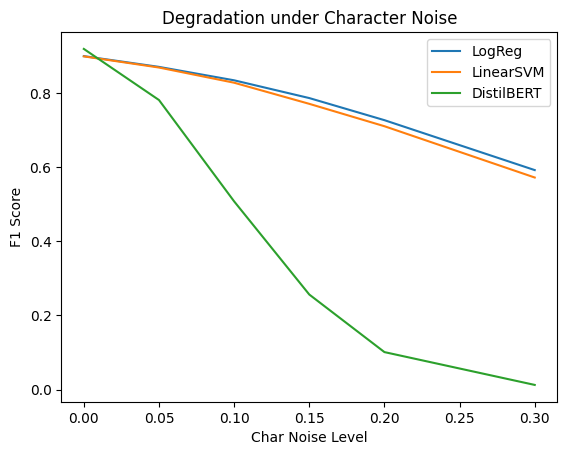

In [ ]:
# @title График деградации моделей при воздействии шума типа "Char noise"

plt.figure()
plt.plot(char_noise_df["noise"], char_noise_df["logreg_f1"], label="LogReg")
plt.plot(char_noise_df["noise"], char_noise_df["svm_f1"], label="LinearSVM")
plt.plot(char_noise_df["noise"], char_noise_df["bert_f1"], label="DistilBERT")

plt.xlabel("Char Noise Level")
plt.ylabel("F1 Score")
plt.title("Degradation under Character Noise")
plt.legend()
plt.show()

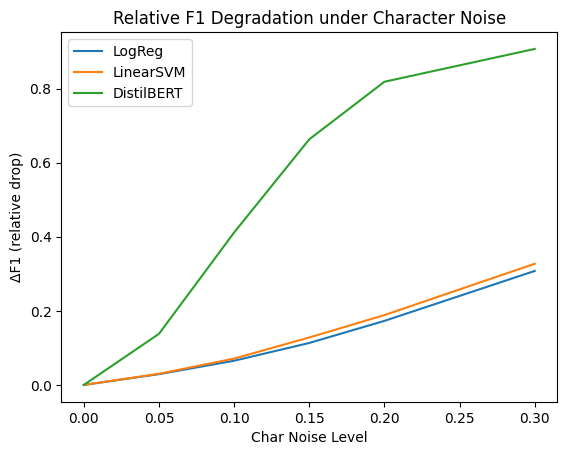

In [ ]:
# @title График деградации F1‑меры при добавлении шума типа "Char Noise" относительно базового уровня (без шума).
# ΔF1 = F1_clean - F1_noise

char_delta_df = char_noise_df.copy()

clean_logreg = char_delta_df.loc[char_delta_df["noise"] == 0.0, "logreg_f1"].values[0]
clean_svm    = char_delta_df.loc[char_delta_df["noise"] == 0.0, "svm_f1"].values[0]
clean_bert   = char_delta_df.loc[char_delta_df["noise"] == 0.0, "bert_f1"].values[0]

char_delta_df["logreg_delta"] = clean_logreg - char_delta_df["logreg_f1"]
char_delta_df["svm_delta"]    = clean_svm    - char_delta_df["svm_f1"]
char_delta_df["bert_delta"]   = clean_bert   - char_delta_df["bert_f1"]

plt.figure()
plt.plot(char_delta_df["noise"], char_delta_df["logreg_delta"], label="LogReg")
plt.plot(char_delta_df["noise"], char_delta_df["svm_delta"], label="LinearSVM")
plt.plot(char_delta_df["noise"], char_delta_df["bert_delta"], label="DistilBERT")

plt.xlabel("Char Noise Level")
plt.ylabel("ΔF1 (relative drop)")
plt.title("Relative F1 Degradation under Character Noise")
plt.legend()
plt.show()

## Эксперимент с шумом типа "word dropout"

Проведение эксперимента

In [ ]:
word_dropout_results = []

for nl in noise_levels:
    print(f"\nWord dropout level: {nl}")

    noisy_texts = [
        apply_word_dropout(t, nl) if nl > 0 else t
        for t in tqdm(X_test_base, leave=False)
    ]

    f1_logreg = evaluate_sklearn_model(best_logreg, noisy_texts)
    f1_svm    = evaluate_sklearn_model(best_svm, noisy_texts)
    f1_bert   = evaluate_bert_model(trainer, noisy_texts)

    word_dropout_results.append({
        "noise": nl,
        "logreg_f1": f1_logreg,
        "svm_f1": f1_svm,
        "bert_f1": f1_bert
    })

word_dropout_df = pd.DataFrame(word_dropout_results)
word_dropout_df


Word dropout level: 0.0


  0%|          | 0/25000 [00:00<?, ?it/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]


Word dropout level: 0.05


  0%|          | 0/25000 [00:00<?, ?it/s]

...

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]


Word dropout level: 0.3


  0%|          | 0/25000 [00:00<?, ?it/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

,noise,logreg_f1,svm_f1,bert_f1
0,0.00,0.899972,0.899286,0.919394
1,0.05,0.897555,0.897603,0.915966
2,0.10,0.892626,0.891636,0.912226
3,0.15,0.891336,0.889040,0.906534
4,0.20,0.887104,0.884628,0.902668
5,0.30,0.879831,0.874835,0.891569


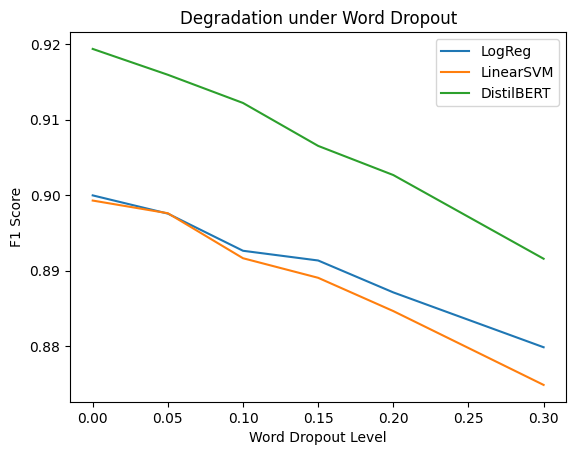

In [ ]:
# @title График деградации моделей при воздействии шума типа "Word Dropout"
plt.figure()
plt.plot(word_dropout_df["noise"], word_dropout_df["logreg_f1"], label="LogReg")
plt.plot(word_dropout_df["noise"], word_dropout_df["svm_f1"], label="LinearSVM")
plt.plot(word_dropout_df["noise"], word_dropout_df["bert_f1"], label="DistilBERT")

plt.xlabel("Word Dropout Level")
plt.ylabel("F1 Score")
plt.title("Degradation under Word Dropout")
plt.legend()
plt.show()

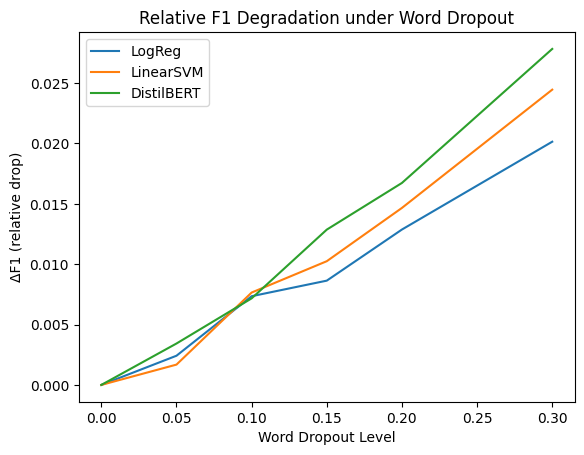

In [ ]:
# @title График деградации F1‑меры при добавлении шума типа "Word Dropout" относительно базового уровня (без шума).

word_delta_df = word_dropout_df.copy()

clean_logreg = word_delta_df.loc[word_delta_df["noise"] == 0.0, "logreg_f1"].values[0]
clean_svm    = word_delta_df.loc[word_delta_df["noise"] == 0.0, "svm_f1"].values[0]
clean_bert   = word_delta_df.loc[word_delta_df["noise"] == 0.0, "bert_f1"].values[0]

word_delta_df["logreg_delta"] = clean_logreg - word_delta_df["logreg_f1"]
word_delta_df["svm_delta"]    = clean_svm    - word_delta_df["svm_f1"]
word_delta_df["bert_delta"]   = clean_bert   - word_delta_df["bert_f1"]

plt.figure()
plt.plot(word_delta_df["noise"], word_delta_df["logreg_delta"], label="LogReg")
plt.plot(word_delta_df["noise"], word_delta_df["svm_delta"], label="LinearSVM")
plt.plot(word_delta_df["noise"], word_delta_df["bert_delta"], label="DistilBERT")

plt.xlabel("Word Dropout Level")
plt.ylabel("ΔF1 (relative drop)")
plt.title("Relative F1 Degradation under Word Dropout")
plt.legend()
plt.show()

## Сводная таблица сравнения 2 методов зашумления

In [ ]:
char_noise_df_ = char_noise_df.copy()
char_noise_df_["noise_type"] = "char_noise"

word_dropout_df_ = word_dropout_df.copy()
word_dropout_df_["noise_type"] = "word_dropout"

robustness_df = pd.concat([char_noise_df_, word_dropout_df_], ignore_index=True)
robustness_df = robustness_df[["noise_type", "noise", "logreg_f1", "svm_f1", "bert_f1"]]
robustness_df.sort_values(["noise_type", "noise"])

,noise_type,noise,logreg_f1,svm_f1,bert_f1
0,char_noise,0.00,0.899972,0.899286,0.919394
1,char_noise,0.05,0.870931,0.869172,0.781491
2,char_noise,0.10,0.834693,0.828170,0.507959
3,char_noise,0.15,0.786745,0.771189,0.256524
4,char_noise,0.20,0.727115,0.710770,0.101151
5,char_noise,0.30,0.592373,0.572313,0.012554
6,word_dropout,0.00,0.899972,0.899286,0.919394
7,word_dropout,0.05,0.897555,0.897603,0.915966
8,word_dropout,0.10,0.892626,0.891636,0.912226
9,word_dropout,0.15,0.891336,0.889040,0.906534


# Оценка результатов

Анализ ошибок DistilBERT при символьном шуме

Количественные результаты показали резкое снижение качества DistilBERT уже при 5% character noise. Для понимания причин деградации проводится качественный анализ предсказаний.

Выделяются случаи, в которых:
- на чистом тексте модель классифицирует отзыв корректно;
- при добавлении 5% символьного шума модель допускает ошибку.

Это позволяет исследовать, как искажение текста влияет на токенизацию и входное представление трансформера.

## Проведение качественного анализа предсказаний

Формирование зашумлённой выборки и получение предсказаний

Для тестовой выборки генерируется версия текста с 5% символьного шума. Далее вычисляются предсказания модели на чистых и зашумлённых данных.

Определяются индексы примеров, где модель:
- классифицирует корректно чистый текст,
- ошибается после добавления шума.

Такие случаи позволяют локализовать влияние искажения входных данных.

In [ ]:
# Чистые тексты
clean_texts = list(X_test_base)

# 5% char noise
noisy_5 = [apply_char_noise(t, 0.05) for t in clean_texts]

# Получаем предсказания
clean_preds = trainer.predict(test_ds).predictions.argmax(axis=1)

noisy_ds_5 = Dataset.from_dict({
    "text": noisy_5,
    "label": y_test
})

noisy_ds_5 = noisy_ds_5.map(lambda x: tokenize_batch(x["text"]), batched=True)
noisy_ds_5.set_format("torch", columns=["input_ids", "attention_mask", "label"])

noisy_preds_5 = trainer.predict(noisy_ds_5).predictions.argmax(axis=1)

# Индексы где:
# чисто — правильно
# 5% шум — неправильно

indices = []
for i in range(len(y_test)):
    if clean_preds[i] == y_test[i] and noisy_preds_5[i] != y_test[i]:
        indices.append(i)

print("Количество таких случаев:", len(indices))

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Количество таких случаев: 3473


Для нескольких выбранных примеров выводятся:

- исходный текст,
- зашумлённая версия,
- предсказания модели до и после искажения.

Это позволяет визуально оценить характер ошибок.

In [ ]:
for idx in indices[:5]:
    print("\n============================")
    print("TRUE LABEL:", y_test[idx])
    print("\n--- CLEAN TEXT ---")
    print(clean_texts[idx][:500])
    print("\n--- NOISY (5%) ---")
    print(noisy_5[idx][:500])
    print("\nPred clean:", clean_preds[idx])
    print("Pred noisy:", noisy_preds_5[idx])


TRUE LABEL: 0

--- CLEAN TEXT ---
isaac florentine has made some of the best western martial arts action movies ever produced. in particular us seals 2, cold harvest, special forces and undisputed 2 are all action classics. you can tell isaac has a real passion for the genre and his films are always eventful, creative and sharp affairs, with some of the best fight sequences an action fan could hope for. in particular he has found a muse with scott adkins, as talented an actor and action performer as you could hope for. this is b

--- NOISY (5%) ---
isaac florentine hs mad some of the best westrenm artial arts action movies ever produced. inlparticula rus seals 2, cold harvest, spceial forces and undisputed 2 are all actien classics. you can tell isaac has a real passion fo rthe genre and his films are alwayg eventful, creative and sharp affairs, with som eof the best fight sequences an action fan could hope for. in particular he has found a mu with scottqadkins, as taelntmd a acthr an

Дополнительно сравниваются результаты WordPiece-токенизации чистого и зашумлённого текста. Это позволяет понять, каким образом символьные искажения трансформируются во входные токены модели.

In [ ]:
example_idx = indices[0]

print("\nCLEAN TOKENS:")
print(tokenizer.tokenize(clean_texts[example_idx])[:40])

print("\nNOISY TOKENS:")
print(tokenizer.tokenize(noisy_5[example_idx])[:40])


CLEAN TOKENS:
['isaac', 'fl', '##ore', '##ntine', 'has', 'made', 'some', 'of', 'the', 'best', 'western', 'martial', 'arts', 'action', 'movies', 'ever', 'produced', '.', 'in', 'particular', 'us', 'seals', '2', ',', 'cold', 'harvest', ',', 'special', 'forces', 'and', 'und', '##is', '##puted', '2', 'are', 'all', 'action', 'classics', '.', 'you']

NOISY TOKENS:
['isaac', 'fl', '##ore', '##ntine', 'hs', 'mad', 'some', 'of', 'the', 'best', 'west', '##ren', '##m', 'art', '##ial', 'arts', 'action', 'movies', 'ever', 'produced', '.', 'in', '##lp', '##art', '##ic', '##ula', 'rus', 'seals', '2', ',', 'cold', 'harvest', ',', 'sp', '##ce', '##ial', 'forces', 'and', 'und', '##is']


## Интерпретация

### 1. Сравнение моделей на чистых данных

На исходном тестовом наборе без искажений получены следующие значения F1-score:

- TF-IDF + Logistic Regression: ~0.900

- TF-IDF + Linear SVM: ~0.899

- DistilBERT: ~0.916

Трансформерная модель демонстрирует прирост порядка +1.7 процентных пункта относительно классических линейных моделей. Несмотря на архитектурную сложность DistilBERT, выигрыш является умеренным, что объясняется спецификой датасета IMDb: задача бинарной классификации отзывов хорошо решается уже на уровне bag-of-words и n-грамм.

Таким образом, на чистых данных линейные модели остаются сильным и конкурентоспособным baseline.

### 2. Устойчивость к символьному шуму (Character Noise)

При добавлении символьных искажений наблюдается резкая деградация качества DistilBERT по сравнению с линейными моделями.

| Уровень шума | LogReg F1 | SVM F1 | BERT F1 |
| ------------ | --------- | ------ | ------- |
| 0%           | 0.8999    | 0.8992 | 0.9193  |
| 5%           | 0.8709    | 0.8691 | 0.7814  |
| 10%          | 0.8346    | 0.8281 | 0.5079  |
| 15%          | 0.7867    | 0.7711 | 0.2565  |

Даже при 5% искажённых символов DistilBERT теряет более 12 пунктов F1, тогда как линейные модели снижаются лишь на ~3 пункта.
При 10–15% шума наблюдается резкое снижение F1-score, приближающееся к случайному угадыванию

<h1> Анализ токенизации </h1>

Рассмотрение конкретных примеров показало, что символьные искажения:

- нарушают структуру субсловных токенов WordPiece,
- приводят к появлению нетипичных фрагментов,
- ухудшают согласованность эмбеддингов.

<h3> Пример </h3>

Токены:
```
['this', 'only', 'gets', 'bash', '##ed', 'because', ...]
```

Токены после зашумления:
```
['this', 'only', 'gets', 'bash', '##ed', ..., 'gap', '##ba', '##e', ...]
```

Даже небольшие опечатки разрушают частотные токены (garbage → gap ##ba ##e), что изменяет входное представление модели.

В отличие от этого, TF-IDF-модель продолжает опираться на оставшиеся корректные n-граммы. Несмотря на потерю части признаков, множество слов остаётся неизменным, что обеспечивает более плавную деградацию качества.

Вывод по char noise

Трансформерная архитектура оказывается значительно более чувствительной к символьным искажениям, чем линейные модели. Это опровергает упрощённое предположение о высокой устойчивости субсловной токенизации к опечаткам.

### 3. Устойчивость к Word Dropout

При использовании шума Word Dropout картина отличается

| Уровень шума | LogReg F1 | SVM F1 | BERT F1 |
| ------------ | --------- | ------ | ------- |
| 0%           | 0.8999    | 0.8992 | 0.9193  |
| 10%          | 0.8926    | 0.8916 | 0.9122  |
| 20%          | 0.8871    | 0.8846 | 0.9026  |
| 30%          | 0.8798    | 0.8748 | 0.8915  |

Здесь деградация DistilBERT значительно более плавная. Даже при удалении 30% слов модель сохраняет F1 ≈ 0.89 и остаётся конкурентоспособной.

Это объясняется тем, что трансформер обучен извлекать смысл из контекста последовательности. Даже при частичной потере токенов семантическая структура предложения сохраняется.

Линейные модели, напротив, зависят от конкретного набора n-грамм, и удаление слов напрямую снижает количество информативных признаков.

Вывод по word dropout

DistilBERT демонстрирует лучшую устойчивость к структурным потерям текста (удаление слов), чем классические модели.

### 4. Сравнительный вывод по типам шума

Полученные результаты показывают, что устойчивость модели определяется не только её архитектурной сложностью, но и типом искажения входных данных:

- Character noise разрушает трансформер сильнее линейных моделей.
- Word dropout оказывает более разрушительное влияние на линейные модели, тогда как трансформер деградирует плавно.
- На чистых данных трансформер обеспечивает умеренное преимущество.

Таким образом, выбор архитектуры должен учитывать предполагаемый тип шума в реальной среде эксплуатации.

# Выводы

В работе проведено сравнительное исследование линейных моделей (TF-IDF + Logistic Regression, TF-IDF + Linear SVM) и трансформерной архитектуры DistilBERT в задаче бинарной классификации тональности, а также проанализирована их устойчивость к различным типам текстового шума.

## Проверка гипотез

### Гипотеза 1

<h3> При отсутствии шума DistilBERT продемонстрирует более высокое качество по F1-score по сравнению с TF-IDF + линейными моделями. </h3>

Подтверждена.

На чистых данных DistilBERT показал F1 ≈ 0.916, тогда как линейные модели достигли ≈ 0.900. Прирост составил около 1.7 процентных пункта. Несмотря на умеренную разницу, трансформерная модель продемонстрировала статистически устойчивое преимущество.

### Гипотеза 2

<h3> При увеличении уровня символного шума качество линейных моделей будет снижаться быстрее из-за зависимости от точных n-грамм. </h3>

Не подтверждена.

Эксперимент показал противоположную картину: при character noise DistilBERT деградировал значительно быстрее. Уже при 5% искажённых символов F1 трансформера снизился более чем на 12 пунктов, тогда как линейные модели потеряли около 3 пунктов.

Анализ токенизации показал, что символьные искажения нарушают структуру субсловных токенов WordPiece, что приводит к резкому ухудшению входных представлений.

### Гипотеза 3

<h3> Трансформер будет демонстрировать большую устойчивость к умеренному шуму благодаря субсловной токенизации. </h3>

Частично опровергнута.

Субсловная токенизация действительно позволяет обрабатывать редкие слова, однако при систематическом символьном искажении структура токенов нарушается, что приводит к значительной деградации качества. Таким образом, устойчивость к опечаткам оказалась ниже ожидаемой.

### Гипотеза 4

<h3> При высоком уровне word-dropout деградация качества DistilBERT будет более выраженной, так как модель чувствительна к контексту последовательности. </h3>

Не подтверждена.

При удалении слов DistilBERT продемонстрировал более плавную деградацию качества по сравнению с линейными моделями. Даже при 30% word-dropout трансформер сохранял F1 ≈ 0.88 и оставался конкурентоспособным.

Это объясняется способностью self-attention механизма извлекать глобальные зависимости даже при частичной потере токенов.

## Ключевые результаты исследования

1. Линейные модели остаются сильным baseline для задачи sentiment analysis и обеспечивают стабильные результаты при низкой вычислительной стоимости.

2. Трансформерная модель обеспечивает умеренный прирост качества на чистых данных, но её устойчивость существенно зависит от типа шума.

3. Character noise разрушает трансформер сильнее, чем линейные модели, из-за нарушения субсловной структуры входных токенов.

4. Word dropout оказывает более мягкое влияние на DistilBERT благодаря контекстной природе self-attention.

5. Устойчивость модели определяется не только архитектурной сложностью, но и характером искажения входных данных.


## Ограничения исследования

- Использовался синтетический шум, который может не полностью отражать реальные пользовательские опечатки.
- Модели не обучались на зашумлённых данных.
- Исследование проведено только на датасете IMDb.
- Не анализировалась устойчивость к семантическим искажениям.

## Возможные направления развития

Перспективным направлением является дообучение трансформеров на зашумлённых данных или применение методов adversarial training для повышения устойчивости к символьным искажениям. Также интерес представляет расширение исследования на другие датасеты и многоязычные корпуса.